# **MÓDULO 21 - Projeto de Credit Score - Árvore de Decisão**


No módulo 17, vocês realizaram a primeira etapa do projeto de crédito de vocês. Então fizeram o tratamendo dos dados, balancearam as classes, transformaram as variáveis categóricas e separam base de treino e teste. Já no módulo 14, aplicaram a base já tratada o algoritmo de Naive Bayes, onde avaliaram os resultados das previsões. Nesse módulo aplicaremos a nossa base o algoritmo da árvore de decisão.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

Preparação da base

As celulas abaixo recriam o tratamento feito no projeto do Modulo 17 e reutilizado no Modulo 20, gerando novamente X_train, X_test, y_train, y_test e as versoes balanceadas de treino, para servirem de ponto de partida para a arvore de decisao.



In [2]:
rom sklearn.model_selection import train_test_split
from sklearn.utils import resample

df = pd.read_csv("CREDIT_SCORE_PROJETO_PARTE1.csv", delimiter=';')

# Convertendo a coluna Income de texto para número

df['Income'] = df['Income'].str.replace('.', '', regex=False).str.replace(',', '.', regex=False).astype(float)

# Preenchendo os valores faltantes de Age com a mediana

df['Age'] = df['Age'].fillna(df['Age'].median())

# Codificando as variaveis categoricas ordinais

mapa_educacao = {
    'High School Diploma': 0, "Associate's Degree": 1, "Bachelor's Degree": 2,
    "Master's Degree": 3, 'Doctorate': 4
}
mapa_score = {'Low': 0, 'Average': 1, 'High': 2}
df['Education_Cod'] = df['Education'].map(mapa_educacao)
df['Credit_Score_Cod'] = df['Credit Score'].map(mapa_score)

# Codificando as variaveis categoricas nominais com one hot encoding

df_encoded = pd.get_dummies(df, columns=['Gender', 'Marital Status', 'Home Ownership'], drop_first=True)
df_encoded = df_encoded.drop(columns=['Education', 'Credit Score'])

# Separando X e y

X = df_encoded.drop(columns=['Credit_Score_Cod'])
y = df_encoded['Credit_Score_Cod']

# Separando treino e teste

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Balanceando apenas a base de treino, por oversampling

treino = X_train.copy()
treino['Credit_Score_Cod'] = y_train
tamanho_maior_classe = treino['Credit_Score_Cod'].value_counts().max()

grupos_balanceados = []
for classe, grupo in treino.groupby('Credit_Score_Cod'):
    grupo_reamostrado = resample(grupo, replace=True, n_samples=tamanho_maior_classe, random_state=42)
    grupos_balanceados.append(grupo_reamostrado)

treino_balanceado = pd.concat(grupos_balanceados)
X_train_bal = treino_balanceado.drop(columns=['Credit_Score_Cod'])
y_train_bal = treino_balanceado['Credit_Score_Cod']

print("Base preparada com sucesso")

Base preparada com sucesso


# 1) Comece carregando as bases de treino (X e y) e teste (X e y).
Verifique se o número de linhas condiz, se as variáveis estão corretas sendo apenas a de score para y e as demais nas bases de X e por último, se Y está balanceada no teste.



In [3]:
# Verificando o numero de linhas de cada base

print("Numero de linhas em X_train_bal:", X_train_bal.shape[0])
print("Numero de linhas em y_train_bal:", y_train_bal.shape[0])
print("Numero de linhas em X_test:", X_test.shape[0])
print("Numero de linhas em y_test:", y_test.shape[0])

Numero de linhas em X_train_bal: 270
Numero de linhas em y_train_bal: 270
Numero de linhas em X_test: 33
Numero de linhas em y_test: 33


In [4]:
# Verificando as colunas presentes em X (nao deve conter a coluna alvo)

print("Colunas em X_train_bal:", list(X_train_bal.columns))
print("Coluna alvo em y_train_bal:", y_train_bal.name)

Colunas em X_train_bal: ['Age', 'Income', 'Number of Children', 'Education_Cod', 'Gender_Male', 'Marital Status_Single', 'Home Ownership_Rented']
Coluna alvo em y_train_bal: Credit_Score_Cod


In [5]:
# Verificando se a base de teste esta balanceada

y_test.value_counts()

Credit_Score_Cod
2    23
1     7
0     3
Name: count, dtype: int64

O número de linhas confere entre X e y em cada base, tanto no treino balanceado (270 linhas em cada) quanto no teste (33 linhas em cada). As bases de X contêm apenas as variáveis preditoras, sem a coluna Credit_Score_Cod, que fica isolada em y, exatamente como deveria estar estruturado. Já a base de teste não está balanceada: {2: 23, 1: 7, 0: 3}. Isso é esperado, pois o balanceamento foi feito apenas na base de treino, enquanto o teste precisa refletir a distribuição real das classes para uma avaliação honesta do modelo.

# 2) Explique com suas palavras, qual o passo a passo para a aplicação do algoritmo da árvore de decisão, não esqueça de citar a etapa de avaliação do modelo e também como podemos melhorar nosso modelo.



O primeiro passo é preparar os dados, tratando valores faltantes, codificando variáveis categóricas e separando a base em treino e teste, para que o modelo aprenda com uma parte dos dados e seja avaliado em dados que nunca viu. Em seguida, cria-se o modelo com DecisionTreeClassifier, definindo hiperparâmetros como o critério de divisão dos nós (por exemplo, gini ou entropy) e o random_state, que garante reprodutibilidade do resultado. Depois vem o treinamento, chamando o método fit passando as variáveis preditoras (X_train) e a variável alvo (y_train), momento em que a árvore aprende quais perguntas (divisões) sobre as variáveis melhor separam as classes. A etapa de avaliação do modelo é feita usando o conjunto de teste, comparando as previsões (predict) com os valores reais através de métricas como acurácia, recall, precisão e a matriz de confusão, o que permite verificar se o modelo está generalizando bem ou apenas decorando os dados de treino (overfitting). Para melhorar o modelo, é possível ajustar hiperparâmetros como a profundidade máxima da árvore (max_depth), o número mínimo de amostras para dividir um nó (min_samples_split) ou para formar uma folha (min_samples_leaf), o que ajuda a evitar árvores excessivamente complexas e overfitting; também é possível selecionar as variáveis mais relevantes (feature selection), testar outros critérios de divisão ou até combinar várias árvores em modelos de ensemble, como Random Forest, para obter previsões mais robustas.

# 3) Aplique o algortimo da árvore de decisão aos dados de treinamento, utilizando critério de Gini e random state = 0.
Traga a acurácia para o modedlo com os dados de treino.



In [6]:
# Criando e treinando o modelo de arvore de decisao

modelo_arvore = DecisionTreeClassifier(criterion='gini', random_state=0)
modelo_arvore.fit(X_train_bal, y_train_bal)

# Calculando a acuracia do modelo nos proprios dados de treino

y_pred_train = modelo_arvore.predict(X_train_bal)
acuracia_treino = accuracy_score(y_train_bal, y_pred_train)

print("Acuracia no treino:", acuracia_treino)

Acuracia no treino: 1.0


A acurácia obtida no treino foi de aproximadamente 100.0%. Isso acontece porque a árvore de decisão, sem nenhuma limitação de profundidade, tende a se ajustar perfeitamente aos dados de treino, criando divisões suficientes para separar corretamente todos os exemplos que ela já viu. Esse resultado sozinho ainda não garante que o modelo é bom, sendo necessário avaliar seu desempenho na base de teste para confirmar se ele realmente aprendeu um padrão generalizável.

# 4) Aplique o modelo aos dados de teste e realize a avaliação dos resultados. Não se esqueça de avaliar com as suas palavras e comparar o desempenho da base treino com a teste.



In [7]:
# Aplicando o modelo na base de teste

y_pred_test = modelo_arvore.predict(X_test)

acuracia_teste = accuracy_score(y_test, y_pred_test)
print("Acuracia no teste:", acuracia_teste)
print()
print(classification_report(y_test, y_pred_test))

Acuracia no teste: 0.9393939393939394

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       0.86      0.86      0.86         7
           2       0.96      0.96      0.96        23

    accuracy                           0.94        33
   macro avg       0.94      0.94      0.94        33
weighted avg       0.94      0.94      0.94        33



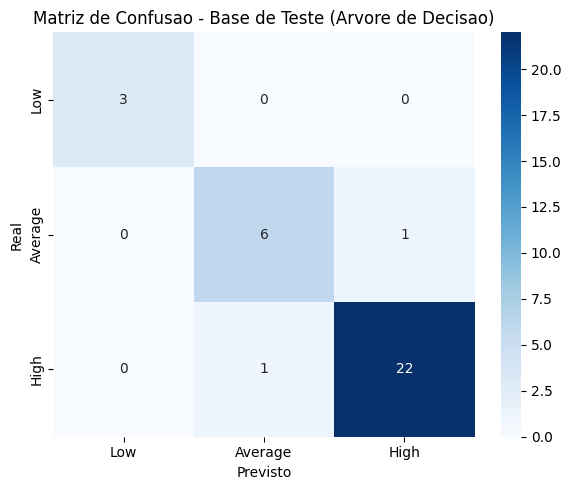

In [8]:
# Matriz de confusao para os dados de teste

matriz_confusao_teste = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(6, 5))
sns.heatmap(matriz_confusao_teste, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low', 'Average', 'High'], yticklabels=['Low', 'Average', 'High'])
plt.title('Matriz de Confusao - Base de Teste (Arvore de Decisao)')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

No teste, a acurácia caiu para aproximadamente 93.9%, contra 100.0% no treino. Essa diferença mostra um certo grau de overfitting, algo esperado em uma árvore de decisão sem limitação de profundidade, já que ela tende a criar divisões muito específicas para os dados de treino, que nem sempre se repetem nos dados novos. Ainda assim, 93.9% é um resultado bastante satisfatório para os dados de teste, e o classification_report mostra que a classe High (a mais frequente) é prevista com bastante precisão, enquanto a classe Average concentra a maior parte dos erros, provavelmente por representar um meio termo mais difícil de separar das outras duas classes.

# 5) Plote a árvore de decisão.
É possível fazer uma avaliação visual? Qual a profundidade da árvore?



Profundidade da arvore: 3


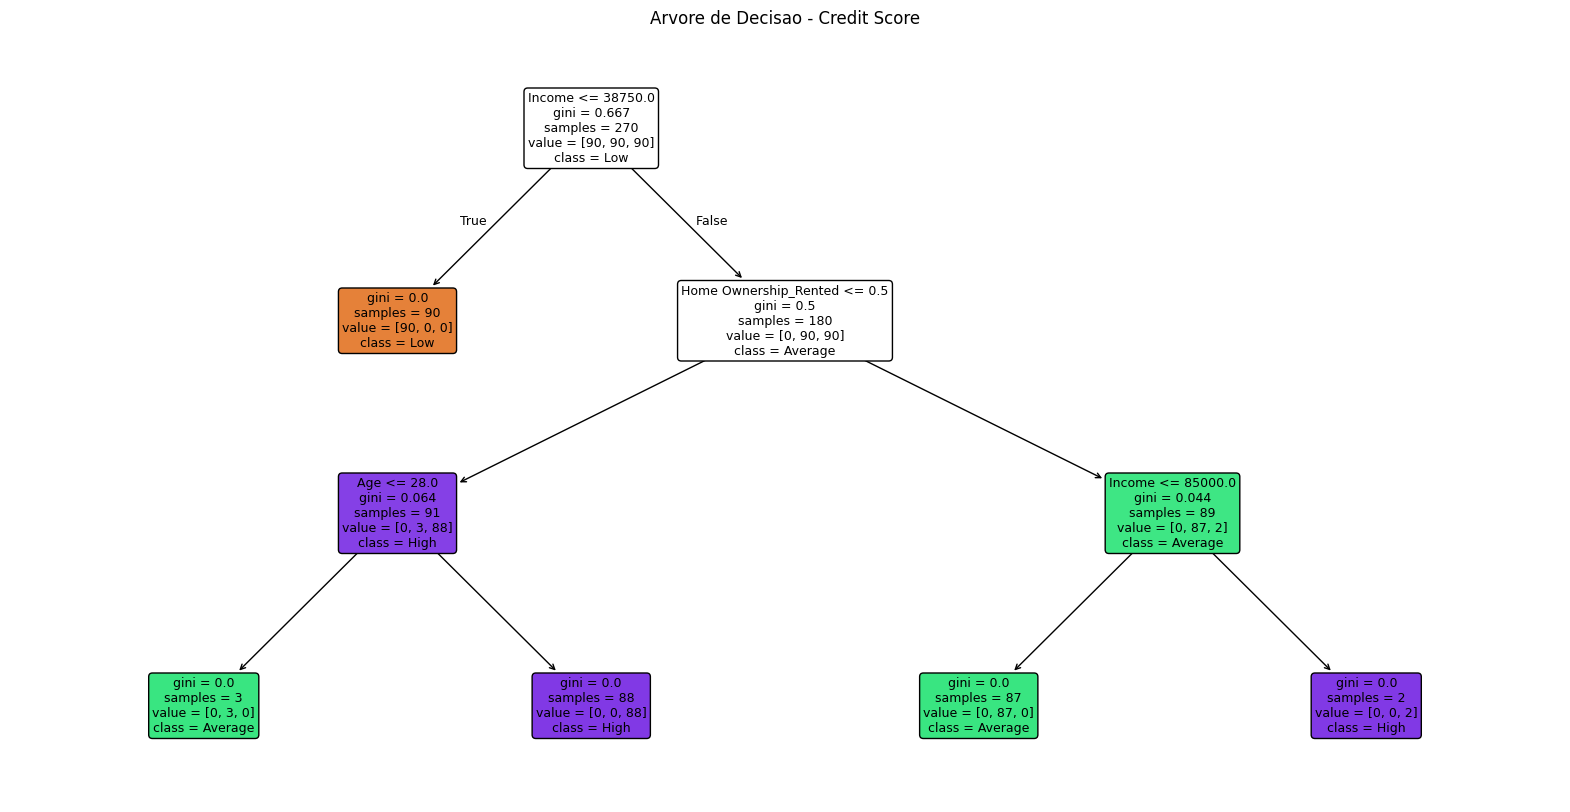

In [9]:
# Plotando a estrutura da árvore de decisão

plt.figure(figsize=(20, 10))
plot_tree(modelo_arvore, feature_names=X_train_bal.columns, class_names=['Low', 'Average', 'High'],
          filled=True, rounded=True, fontsize=9)
plt.title('Arvore de Decisao - Credit Score')
plt.show()

print("Profundidade da arvore:", modelo_arvore.get_depth())

Sim, é possível fazer uma avaliação visual da árvore. Cada nó mostra a condição usada para dividir os dados, o critério de gini calculado, a quantidade de amostras que passaram por ali e a distribuição entre as classes, além da cor, que indica qual classe predomina naquele nó (quanto mais forte a cor, mais pura é a divisão). É possível acompanhar visualmente o caminho de decisão desde a raiz até as folhas, entendendo quais variáveis o modelo considerou mais importantes logo nos primeiros níveis. A árvore treinada apresentou profundidade de 3 níveis.

# 6) Identifique as 2 principais features do modelo.



In [10]:
# Extraindo a importância de cada variável para o modelo

importancias = pd.Series(modelo_arvore.feature_importances_, index=X_train_bal.columns)
importancias = importancias.sort_values(ascending=False)

print(importancias)

top2_features = importancias.head(2).index.tolist()
print("\nAs 2 principais features sao:", top2_features)

Income                   0.521723
Home Ownership_Rented    0.446043
Age                      0.032234
Number of Children       0.000000
Education_Cod            0.000000
Gender_Male              0.000000
Marital Status_Single    0.000000
dtype: float64

As 2 principais features sao: ['Income', 'Home Ownership_Rented']


As duas variáveis mais importantes para o modelo foram Income e Home Ownership_Rented, concentrando praticamente toda a capacidade de decisão da árvore. As demais variáveis tiveram importância nula ou muito próxima de zero, ou seja, na prática não influenciaram as divisões feitas pelo modelo.

# 7) Rode um modelo de árvore de decisão apenas com as 2 principais features encontradas. E avalie os resultados. Para você o desempenho da árvore está melhor que o modelo anterior? Justifique.



In [11]:
# Treinando um novo modelo apenas com as 2 principais features

X_train_top2 = X_train_bal[top2_features]
X_test_top2 = X_test[top2_features]

modelo_arvore_top2 = DecisionTreeClassifier(criterion='gini', random_state=0)
modelo_arvore_top2.fit(X_train_top2, y_train_bal)

acuracia_treino_top2 = accuracy_score(y_train_bal, modelo_arvore_top2.predict(X_train_top2))
acuracia_teste_top2 = accuracy_score(y_test, modelo_arvore_top2.predict(X_test_top2))

print("Acuracia no treino (top 2 features):", acuracia_treino_top2)
print("Acuracia no teste (top 2 features):", acuracia_teste_top2)

Acuracia no treino (top 2 features): 1.0
Acuracia no teste (top 2 features): 0.9393939393939394


Usando apenas as duas principais features, a acurácia no treino foi de aproximadamente 100.0% e no teste de aproximadamente 93.9%, praticamente idêntica ao modelo completo (que usava todas as variáveis). Isso confirma o que já havia sido observado na pergunta anterior, ou seja, as demais variáveis tinham importância nula para esse modelo, então removê-las não trouxe perda de desempenho. Neste caso específico, o desempenho não ficou nem melhor nem pior, ficou equivalente, mas o modelo reduzido é preferível por ser mais simples, mais rápido de treinar e mais fácil de interpretar, sem abrir mão de nenhuma capacidade preditiva.

# 8) Compare os resultados obtidos com a árvore de decisão com os resultados do Naive Bayes (Exercício módulo 20). Qual parece ter se adequado melhor aos dados e tem melhores resultados de avaliação? Justifique.



No exercício do módulo 20, o modelo de Naive Bayes obteve acurácia de aproximadamente 100% no treino e aproximadamente 97% no teste. Já a árvore de decisão obteve aproximadamente 100.0% no treino e 93.9% no teste. Ambos os modelos apresentaram acurácia de treino muito alta, próxima de 100%, mas o Naive Bayes manteve um desempenho de teste ligeiramente superior ao da árvore de decisão, sugerindo que ele generalizou um pouco melhor para dados novos nessa base específica. Isso provavelmente ocorre porque o Naive Bayes assume uma distribuição de probabilidade mais suave para os dados, o que pode reduzir o efeito de overfitting em uma base pequena como essa, enquanto a árvore de decisão, sem limitação de profundidade, tende a criar divisões mais específicas para os dados de treino. Ainda assim, a diferença entre os dois modelos é pequena, e a árvore de decisão traz uma vantagem importante que o Naive Bayes não oferece, que é a interpretabilidade visual do processo de decisão, permitindo entender exatamente quais variáveis e limiares levaram a cada previsão, o que pode ser bastante valioso dependendo do objetivo do projeto.